In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gold_c = '#ffb30f'  # Yellow
blue_c = "#00498a"  # Blue
red_c = "#d73027"   # Red
lblue_c = "#79bde9"  # Highlight color

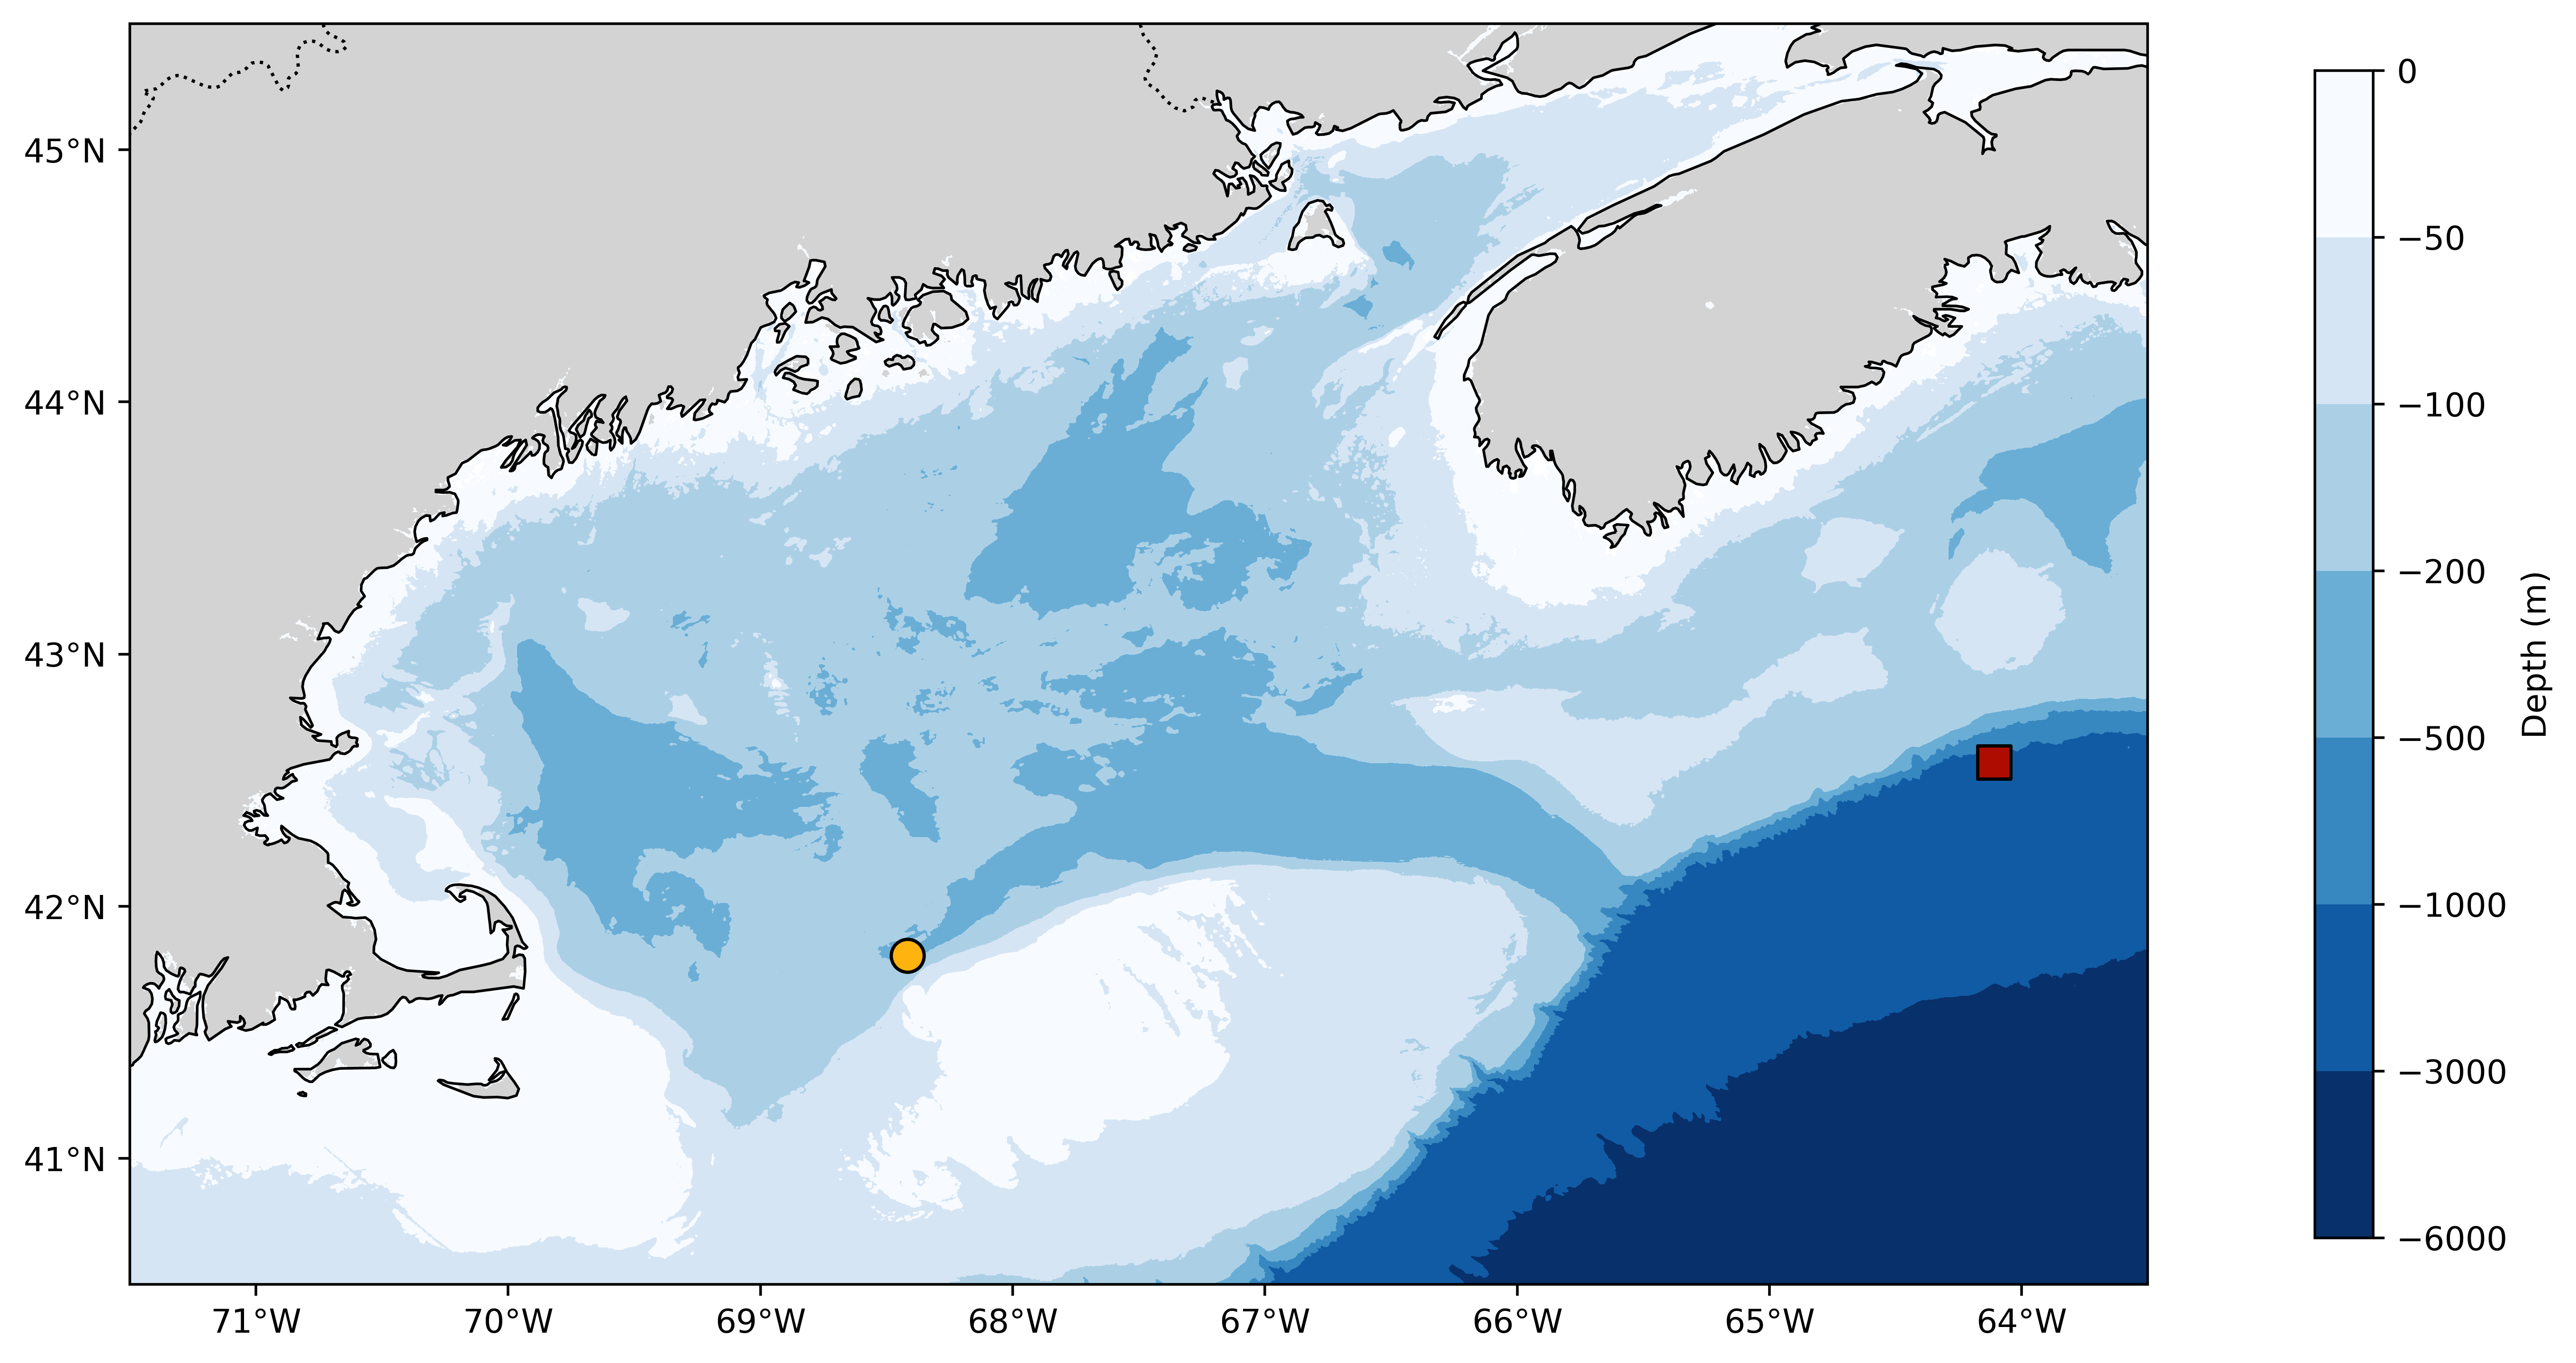

In [7]:
#Figure 1

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
from netCDF4 import Dataset
from matplotlib.colors import BoundaryNorm

bathymetry_file = '/Users/jill.herlinger/Downloads/GEBCO_13_Apr_2026_135f6be845bc/gebco_2024_n46.0_s40.0_w-72.0_e-60.0.nc'
data = Dataset(bathymetry_file)

lons = data.variables['lon'][:]
lats = data.variables['lat'][:]
bathymetry = data.variables['elevation'][:]
extent = [-71.5, -63.5, 40.5, 45.5]

bathymetry_data = np.ma.masked_greater(bathymetry, 0)

lon_mask = (lons >= extent[0]) & (lons <= extent[1])
lat_mask = (lats >= extent[2]) & (lats <= extent[3])
lon_grid, lat_grid = np.meshgrid(lons[lon_mask], lats[lat_mask])
bathymetry_data = bathymetry_data[lat_mask, :][:, lon_mask]

custom_levels = [-6000, -3000, -1000, -500, -200, -100, -50, 0]
cmap = plt.get_cmap('Blues_r')
cmap.set_bad(color='gray')
norm = BoundaryNorm(custom_levels, ncolors=cmap.N, clip=True)

core_lat=41.803548
core_lon=-68.416713
score_lat=42.57
score_lon=-64.11

fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={'projection': ccrs.PlateCarree()}, dpi=500)
ax.set_extent(extent, crs=ccrs.PlateCarree())
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

contour = ax.contourf(lon_grid, lat_grid, bathymetry_data, levels=custom_levels, cmap=cmap, norm=norm)

ax.scatter(core_lon, core_lat, color='#ffb30f', edgecolors='black', s=100, transform=ccrs.PlateCarree())
ax.scatter(score_lon, score_lat, color='#ae0c00', marker='s', edgecolors='black', s=100, transform=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, color='lightgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':')

def ticks():
    xticks = np.arange(-71, -63, 1)
    yticks = np.arange(41, 46, 1)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.spines['geo'].set_visible(True)

    ax.tick_params(axis='x', top=False, labeltop=False,
                   bottom=True, labelbottom=True, color='black')
    ax.tick_params(axis='y', right=False, labelright=False,
                   left=True, labelleft=True, color='black')
    
ticks()

cbar = fig.colorbar(contour, ax=ax, orientation='vertical', shrink=0.8, pad=0.065)
cbar.set_label('Depth (m)')

plt.show()

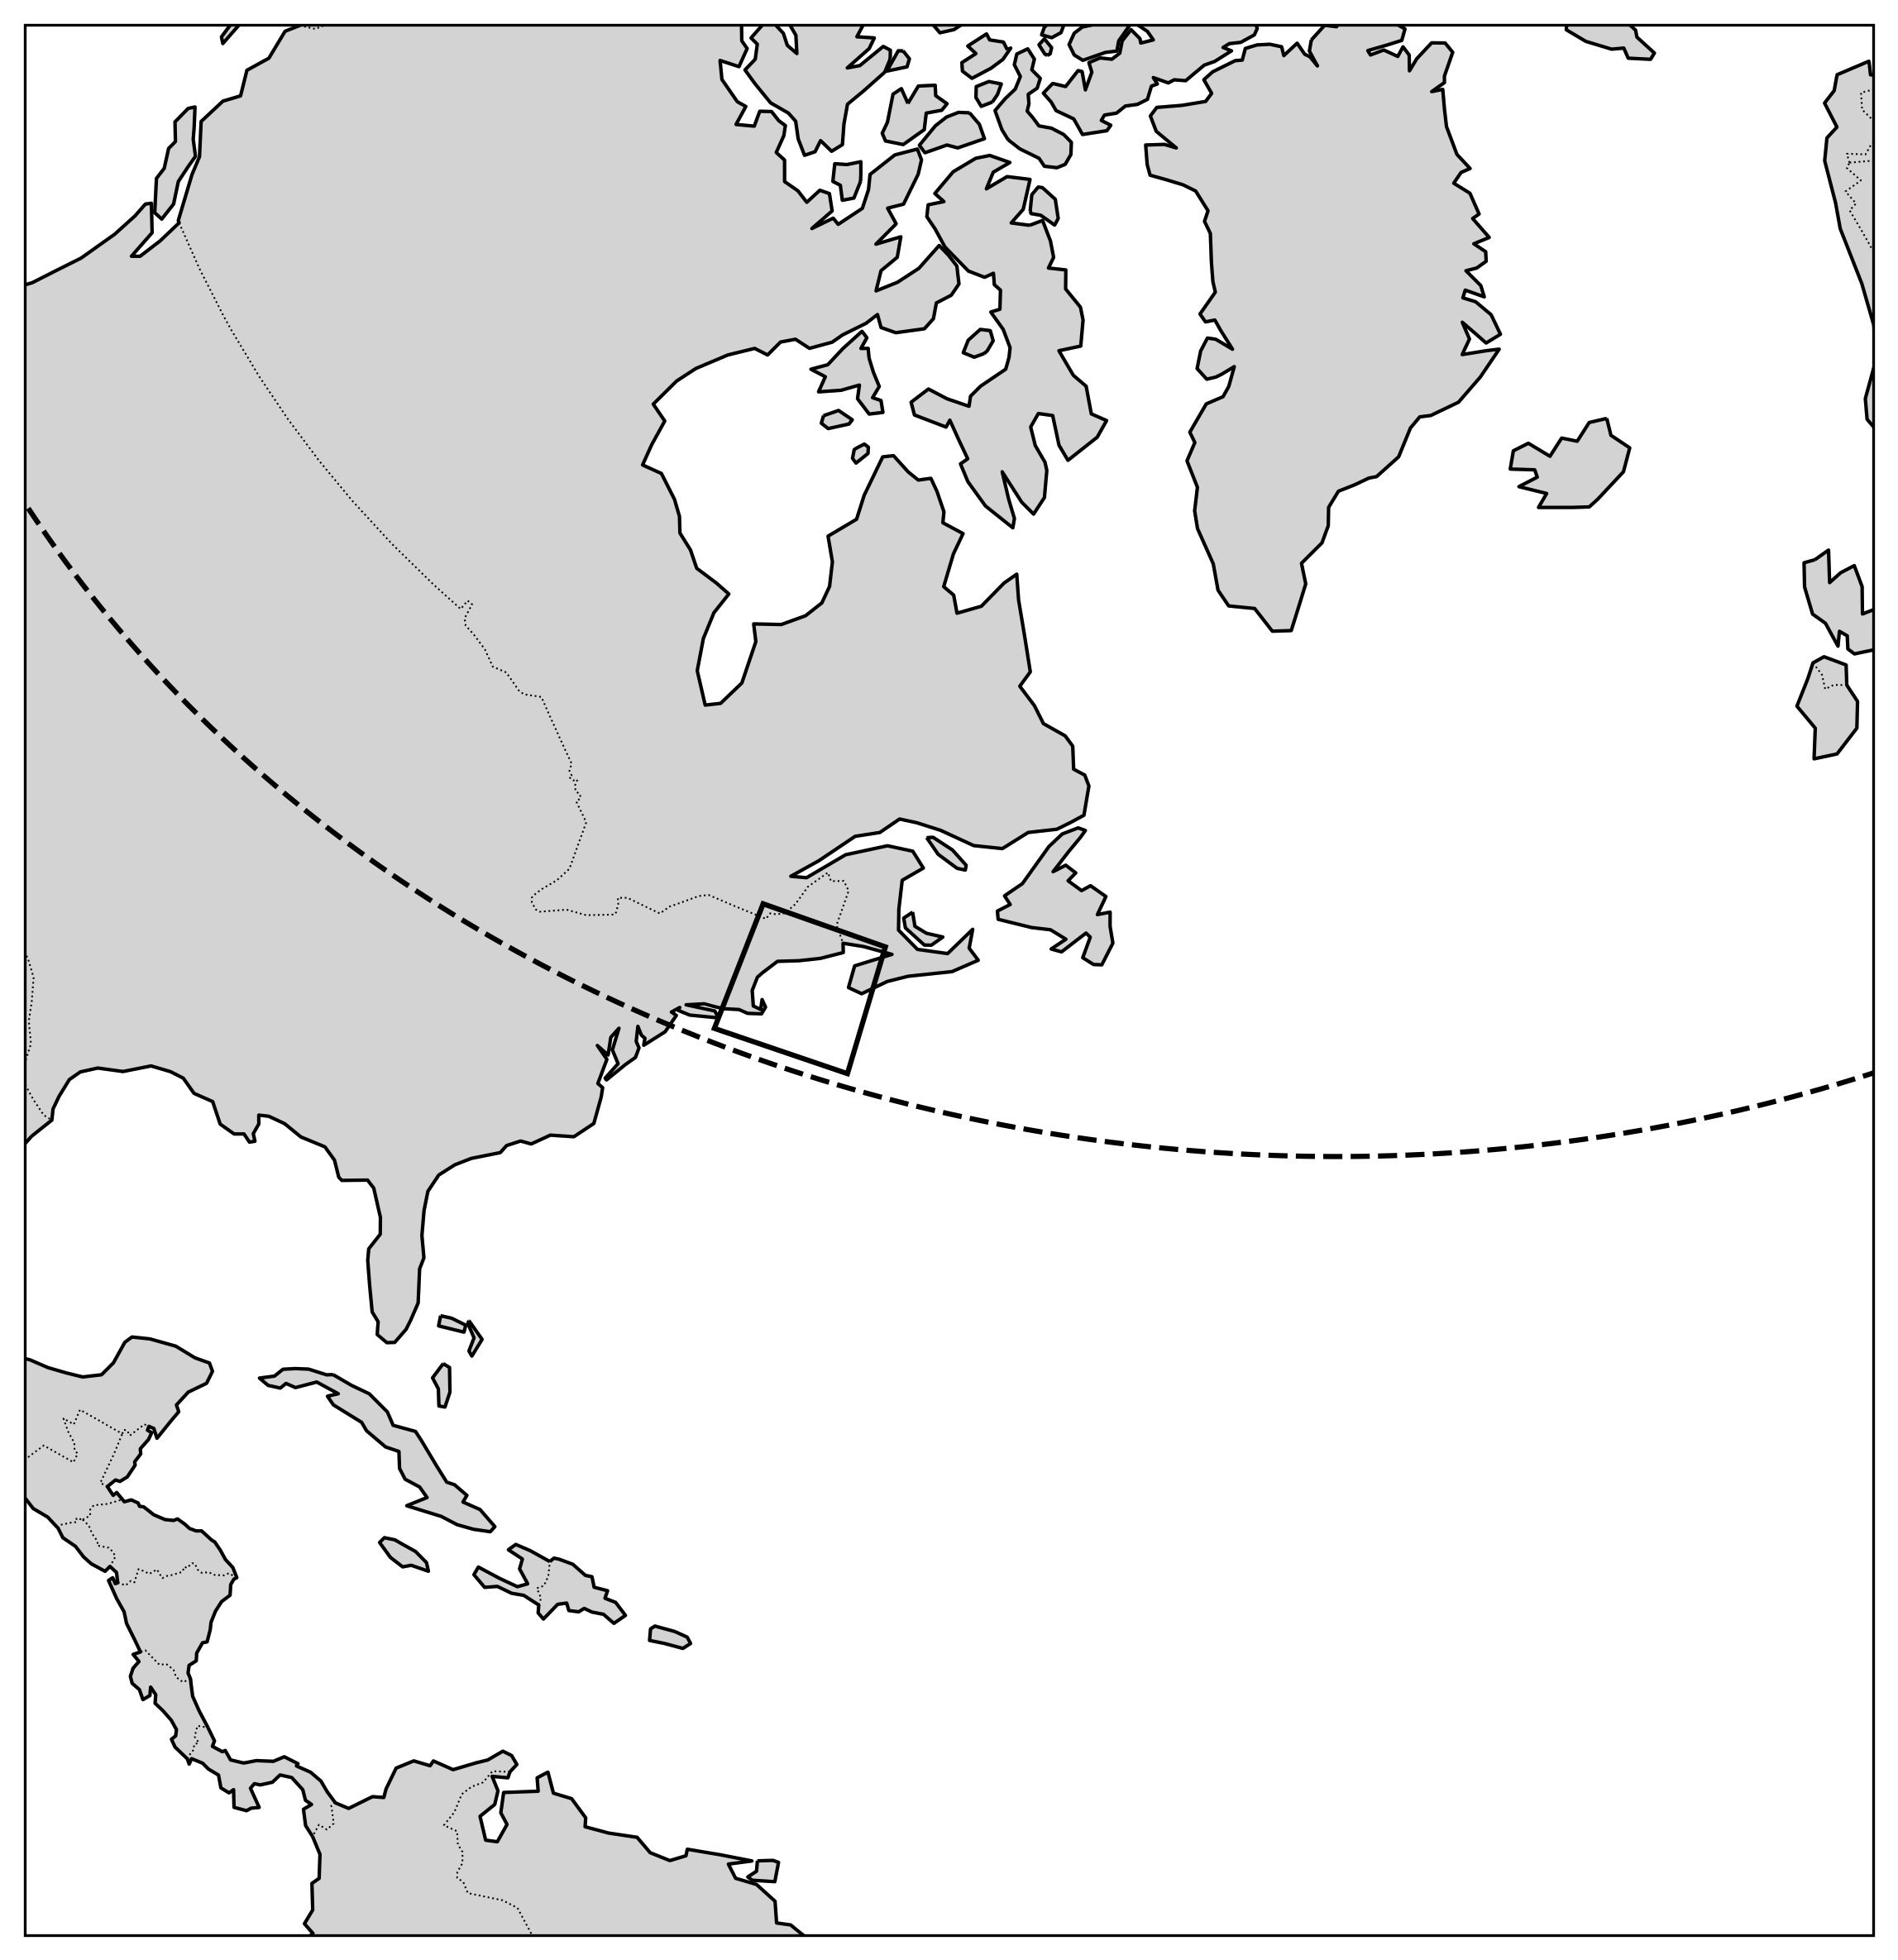

In [8]:
#Figure 1 inset
import matplotlib.patches as mpatches

gom_extent = [-71.95, -64.89, 40.51, 45.49]
proj = ccrs.AzimuthalEquidistant(central_longitude=-40, central_latitude=40)
plate_crs = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': proj}, dpi=300)
ax.set_global()
ax.coastlines()

ax.add_feature(cfeature.OCEAN, color='white')
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

ax.set_extent([-90, -20, 10, 80], crs=ccrs.PlateCarree())

lon_min, lon_max, lat_min, lat_max = gom_extent
rect = mpatches.Rectangle(
    (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
    transform=plate_crs,  
    facecolor='none', edgecolor='black', linewidth=1.5, zorder=5
)
ax.add_patch(rect)

lon_line = np.linspace(-180, 180, 500)
lat_line = 40 * np.ones_like(lon_line)

ax.plot(lon_line, lat_line, color='black', linestyle='--', linewidth=1.5, transform=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

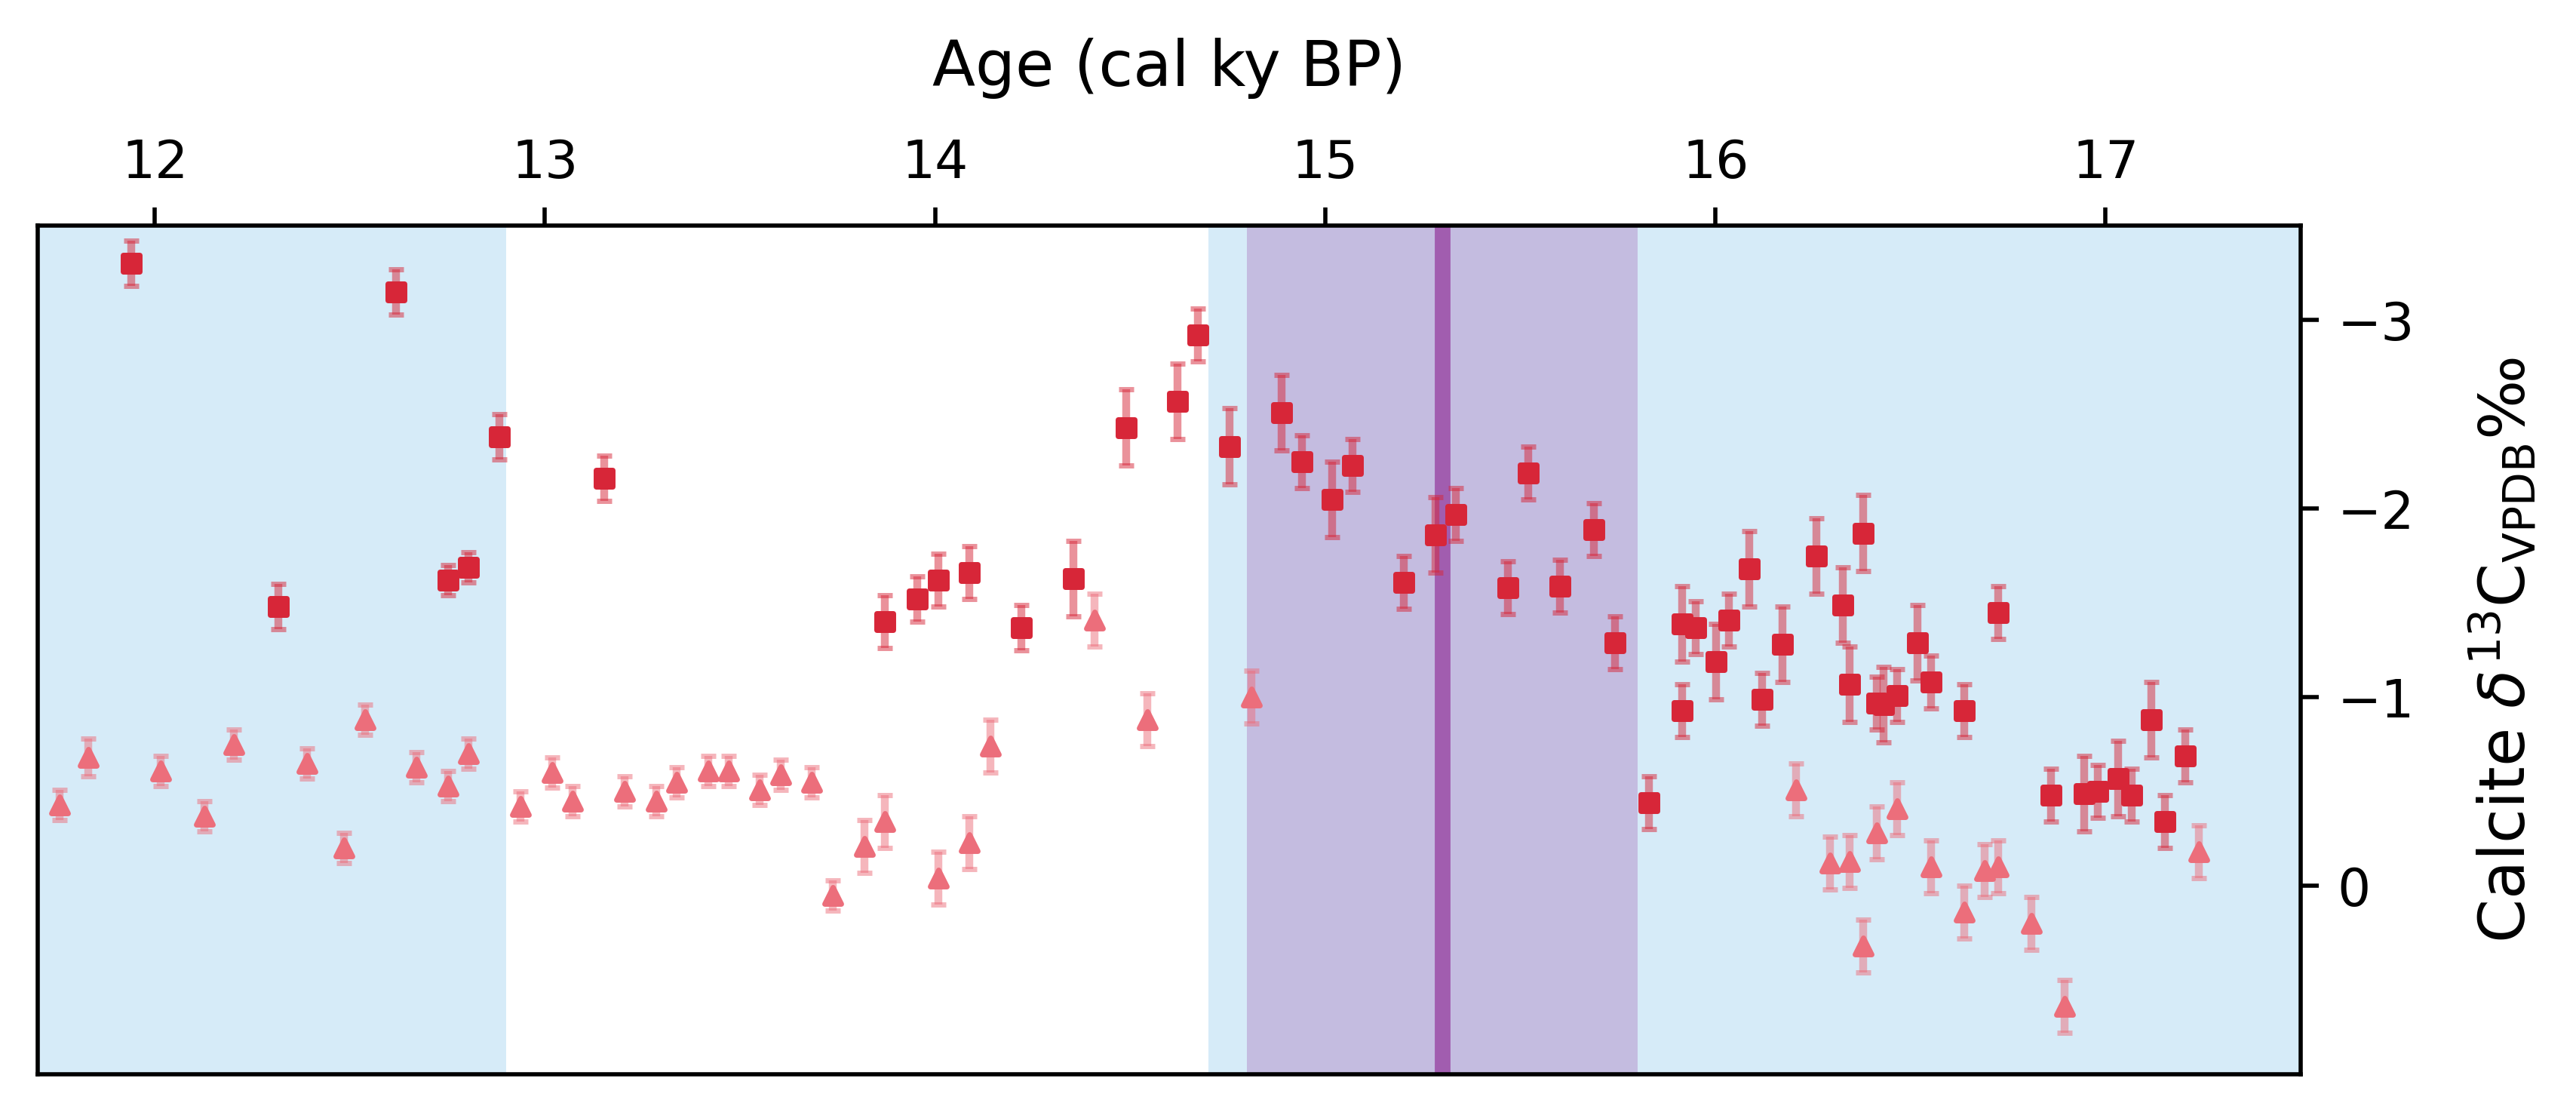

In [9]:
#Figures 3 and 4

Nlab='/Users/jill.herlinger/Documents/Maine Research/data/d18O/GGC40_Nlab_18O.xlsx'
Ihel='/Users/jill.herlinger/Documents/Maine Research/data/d18O/GGC40_Ihel_18O.xlsx'

df_nlab = pd.read_excel(Nlab)
df_nlab = df_nlab[df_nlab['Reported primary d18O (per mil VPDB)'] < 7]

df_ihel = pd.read_excel(Ihel)
df_ihel = df_ihel[df_ihel['Reported primary d18O (per mil VPDB)'] < 7]

X_n=df_nlab['mean'].values/1000
Y_n=df_nlab['Reported primary d13C (per mil VPDB)'].values
Y_n_err=(df_nlab['d13C error'].values)*2

X_i=df_ihel['mean'].values/1000
Y_i=df_ihel['Reported primary d13C (per mil VPDB)'].values
Y_i_err=(df_ihel['d13C error'].values)*2

fig = plt.figure(figsize=(8, 3), dpi=500)

ax = fig.add_axes([0.15, 0.2, 0.75, 0.75])

plt.sca(ax)

plt.tick_params(axis='y', labelsize=10)
plt.tick_params(axis='x', labelsize=10)
plt.ylabel("Label", labelpad=10)
plt.xlabel("Label", labelpad=10)

plt.xlim(11.7, 17.5)
plt.ylim(1, -3.5)

plt.yticks([0, -1, -2, -3])

plt.axvspan(12.9, 11.7, facecolor=lblue_c, alpha=0.3, edgecolor="none", zorder=-5) 
plt.axvspan(18.0, 14.7, facecolor=lblue_c, alpha=0.3, edgecolor="none", zorder=-5)

plt.axvline(x=15.3, color='purple', linestyle='-', linewidth=3, zorder=-4, alpha=0.5)
plt.axvspan(14.8, 15.8, facecolor='purple', edgecolor="none", zorder=-5, alpha=0.2)

plt.xlabel('Age (cal ky BP)', fontsize=12)
plt.ylabel(r"Calcite $\delta^{13}\mathrm{C}_{\mathrm{VPDB}}$‰", fontsize=12)

color='#D72638'
lighter='#EC6E7B'

plt.scatter(X_n, Y_n, marker='s', s=10, color=color, edgecolor=color, zorder=1, label='$\it{N. labradorica}$')
plt.errorbar(X_n, Y_n, yerr=Y_n_err, linestyle=None, color=color, capsize=1.5, alpha=0.5, fmt='none', zorder=-1)

plt.scatter(X_i, Y_i, marker='^', s=10, color=lighter, edgecolor=lighter, zorder=1, label='$\it{I. helenae/norcrossi}$')
plt.errorbar(X_i, Y_i, yerr=Y_i_err, linestyle=None, color=lighter, capsize=1.5, alpha=0.5, fmt='none', zorder=-1)

ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

#plt.legend(loc='upper right')

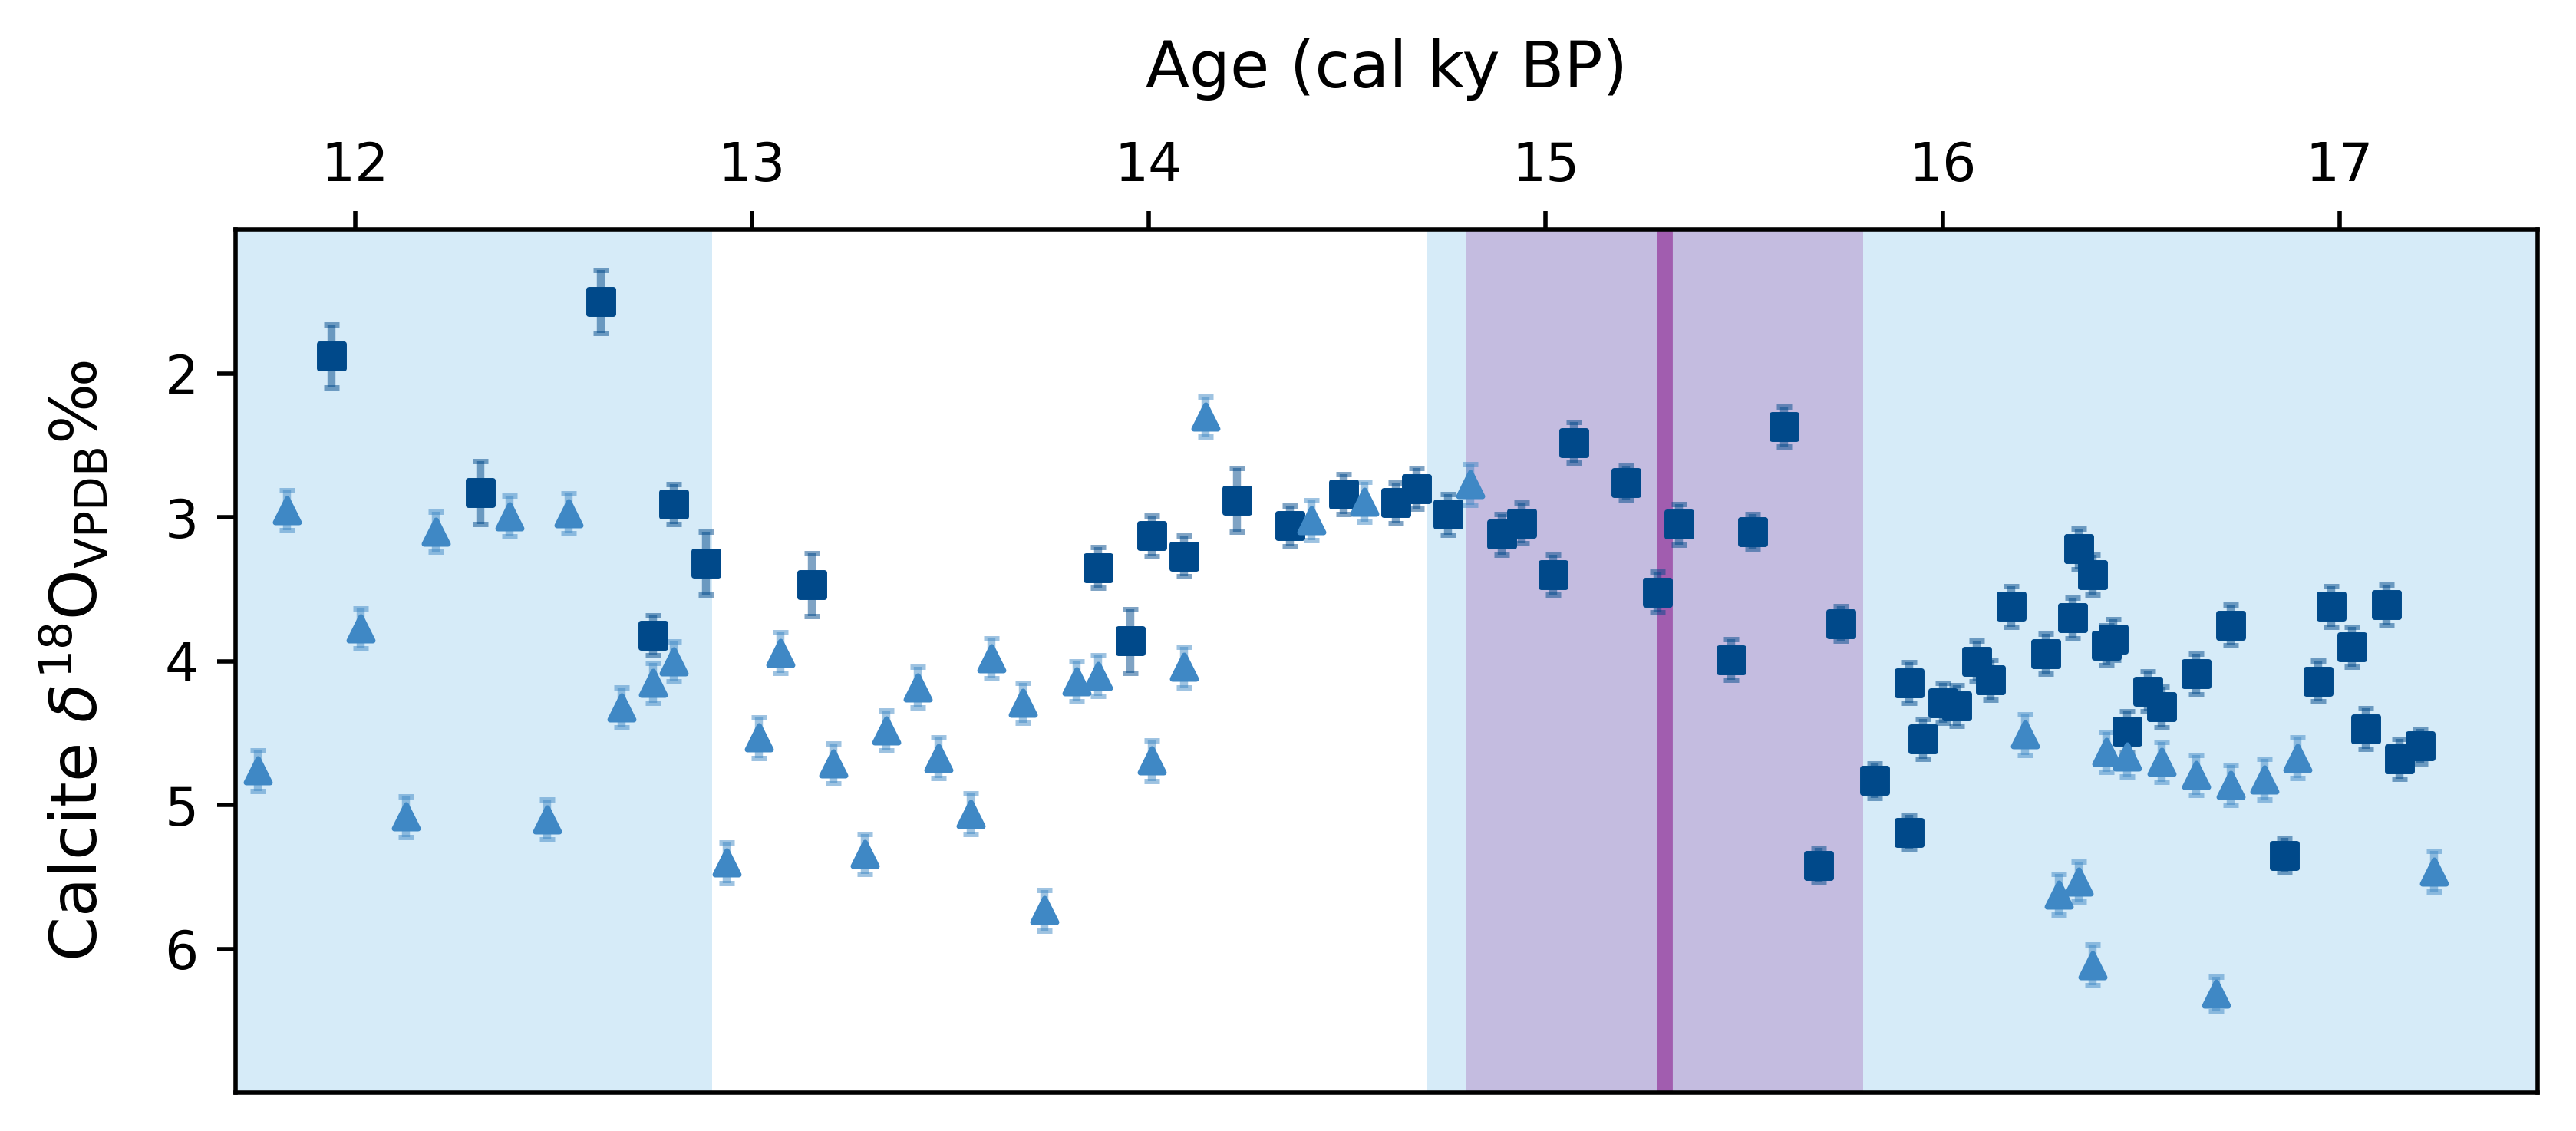

In [10]:
X_n=df_nlab['mean'].values/1000
Y_n=(df_nlab['Reported primary d18O (per mil VPDB)'].values)-0.90 #Vital effect correction
Y_n_err=(df_nlab['d18O error'].values)*2

X_i=df_ihel['mean'].values/1000
Y_i=(df_ihel['Reported primary d18O (per mil VPDB)'].values)-0.298 #Vital effect correction
Y_i_err=(df_ihel['d18O error'].values)*2

fig = plt.figure(figsize=(8, 3), dpi=500)
ax = fig.add_axes([0.15, 0.2, 0.75, 0.75])
plt.sca(ax)

plt.tick_params(axis='y', labelsize=10)
plt.tick_params(axis='x', labelsize=10)
plt.ylabel("Label", labelpad=10)
plt.xlabel("Label", labelpad=10)

ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.xlim(11.7, 17.5)
plt.ylim(7, 1)

plt.yticks([2, 3, 4, 5, 6])

plt.axvspan(12.9, 11.7, facecolor=lblue_c, alpha=0.3, edgecolor="none", zorder=-5)  # Younger Dryas
plt.axvspan(18.0, 14.7, facecolor=lblue_c, alpha=0.3, edgecolor="none", zorder=-5)  # Heinrich Stadial 1

plt.axvline(x=15.3, color='purple', linestyle='-', linewidth=3, zorder=-4, alpha=0.5) # Eastern Maine Degl
plt.axvspan(14.8, 15.8, facecolor='purple', alpha=0.2, edgecolor="none", zorder=-5)

plt.xlabel('Age (cal ky BP)', fontsize=12)
plt.ylabel(r"Calcite $\delta^{18}\mathrm{O}_{\mathrm{VPDB}}$‰", fontsize=12)

clr='#3F88C5'

plt.scatter(X_n, Y_n, marker='s', s=20, color=blue_c, edgecolor=blue_c, zorder=1, label='$\it{N. labradorica}$')
plt.errorbar(X_n, Y_n, yerr=Y_n_err, linestyle=None, color=blue_c, capsize=1.5, alpha=0.5, fmt='none', zorder=-1)

plt.scatter(X_i, Y_i, marker='^', s=20, color=clr, edgecolor=clr, zorder=1, label='$\it{I. helenae/norcrossi}$')
plt.errorbar(X_i, Y_i, yerr=Y_i_err, linestyle=None, color=clr, capsize=1.5, alpha=0.5, fmt='none', zorder=-1)

#plt.legend(loc='lower left')

plt.show()

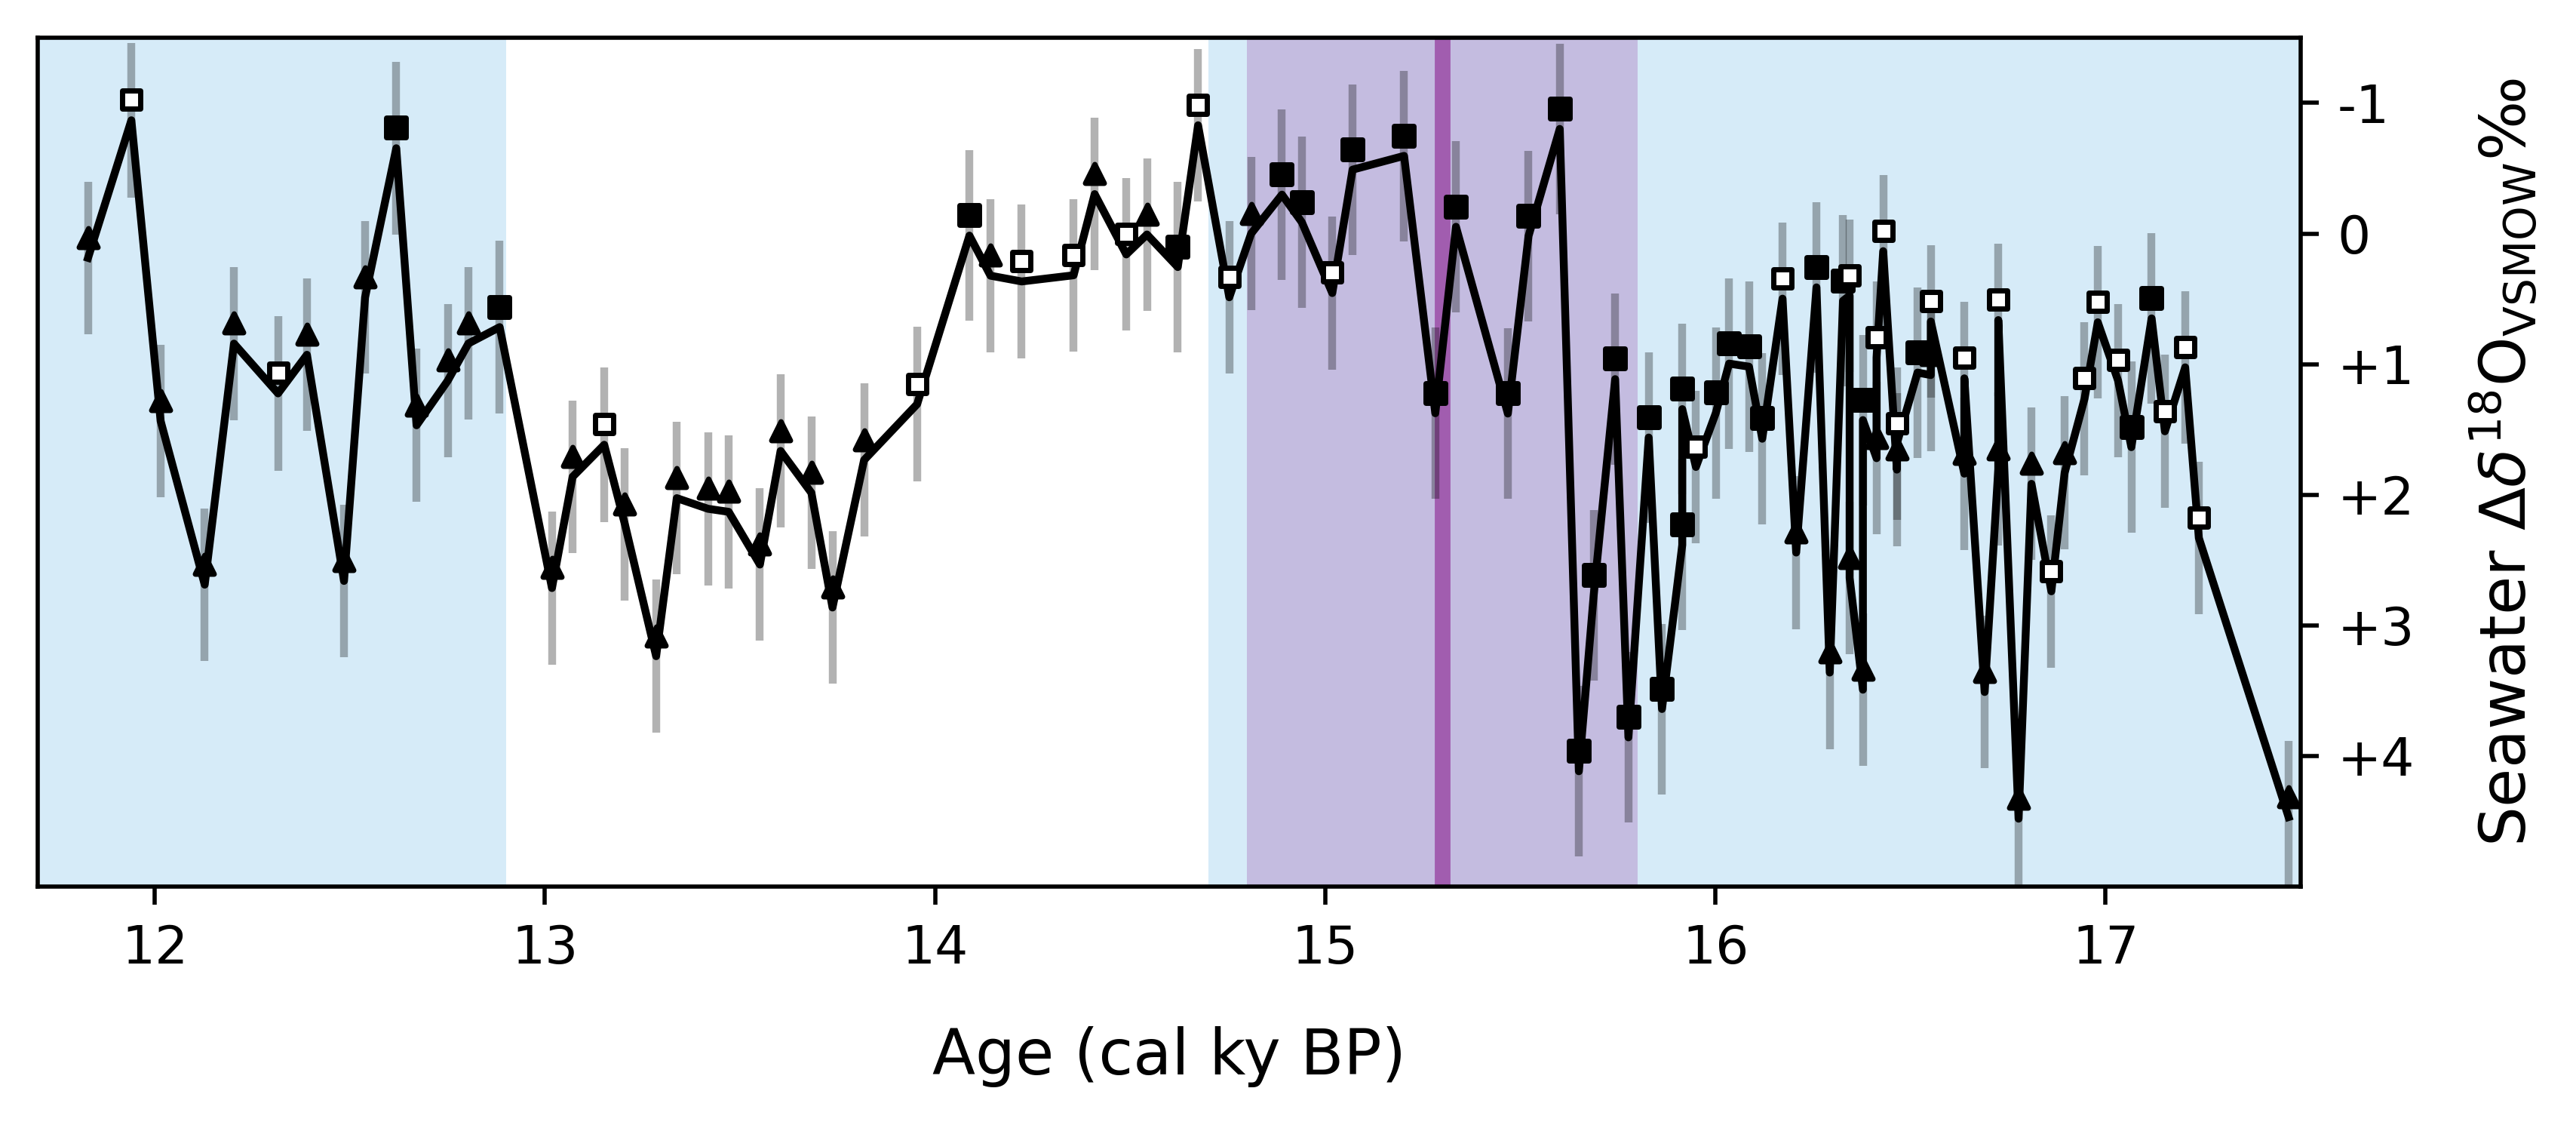

In [11]:
from matplotlib.ticker import FuncFormatter

path='/Users/jill.herlinger/Documents/Maine Research/data/Paired d18O and Temp/EN669_GGC-40_Pairedd18Osw_Finaldataset.xlsx'

file = pd.read_excel(path, header=1)
file = file[file['mean'] > 11700]
file = file.dropna(subset=['Bemis d18Osw'])
file = file.sort_values(by='mean')

file_n=file[file['Plot as'] == "N. labradorica"]
file_i=file[file['Plot as'] == "I. helenae/norcrossi"]
file_nw=file[file['Plot as'] == "N. labradorica with I. helenae/norcrossi paleotemperature"]

path = '/Users/jill.herlinger/Documents/Maine Research/data/Paired d18O and Temp/EN669_GGC-40_Pairedd18Osw_Finaldataset.xlsx'
file = pd.read_excel(path, header=1)

fig = plt.figure(figsize=(8, 3), dpi=500)
ax = fig.add_axes([0.15, 0.2, 0.75, 0.75])
plt.sca(ax)

plt.tick_params(axis='y', labelsize=10)
plt.tick_params(axis='x', labelsize=10)
plt.ylabel("Label", labelpad=10)
plt.xlabel("Label", labelpad=10)

plt.xlim(11.7, 17.5)
plt.ylim(5, -1.5)

plt.axvspan(12.9, 11.7, facecolor=lblue_c, alpha=0.3, zorder=-5) 
plt.axvspan(18.0, 14.7, facecolor=lblue_c, alpha=0.3, zorder=-5) 
plt.axvline(x=15.3, color='purple', linestyle='-', linewidth=3, zorder=-4, alpha=0.5)        
plt.axvspan(14.8, 15.8, facecolor='purple', alpha=0.2, edgecolor="none", zorder=-5)

plt.xlabel('Age (cal ky BP)', fontsize=12)
plt.ylabel(r"Seawater Δ$\delta^{18}\mathrm{O}_{\mathrm{VSMOW}}$‰", fontsize=12)

X = file['mean'] / 1000
Y = file['Bemis d18Osw']
Y_err = file['ERROR']
mask = X.notna() & Y.notna() & Y_err.notna()

X = X[mask]
Y = Y[mask]
Y_err = Y_err[mask]

Xn = file_n['mean'] / 1000
Yn = file_n['Bemis d18Osw']- 0.156 

mask = Xn.notna() & Yn.notna()
Xn = Xn[mask]
Yn = Yn[mask]

Xi = file_i['mean'] / 1000
Yi = file_i['Bemis d18Osw']- 0.156

mask = Xi.notna() & Yi.notna()
Xi = Xi[mask]
Yi = Yi[mask]

Xnw = file_nw['mean'] / 1000
Ynw = file_nw['Bemis d18Osw']- 0.156 

mask = Xnw.notna() & Ynw.notna()
Xnw = Xnw[mask]
Ynw = Ynw[mask]

plt.plot(X, Y, c='black')
plt.errorbar(X, Y, yerr=Y_err, color='black', alpha=0.3, linestyle='none')

plt.scatter(Xn,Yn, s=13, marker='s', c='black', zorder=10)
plt.scatter(Xi, Yi, s=13, marker='^', c='black', zorder=10)
plt.scatter(Xnw, Ynw, s=12, marker='s', c='white', edgecolor='black', zorder=10)

plt.yticks([-1, 0, 1, 2, 3, 4])

def signed_formatter(x, pos):
    if x > 0:
        return f"+{x:g}"
    elif x < 0:
        return f"{x:g}" 
    else:
        return "0"

ax.yaxis.set_major_formatter(FuncFormatter(signed_formatter))

ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

plt.show()

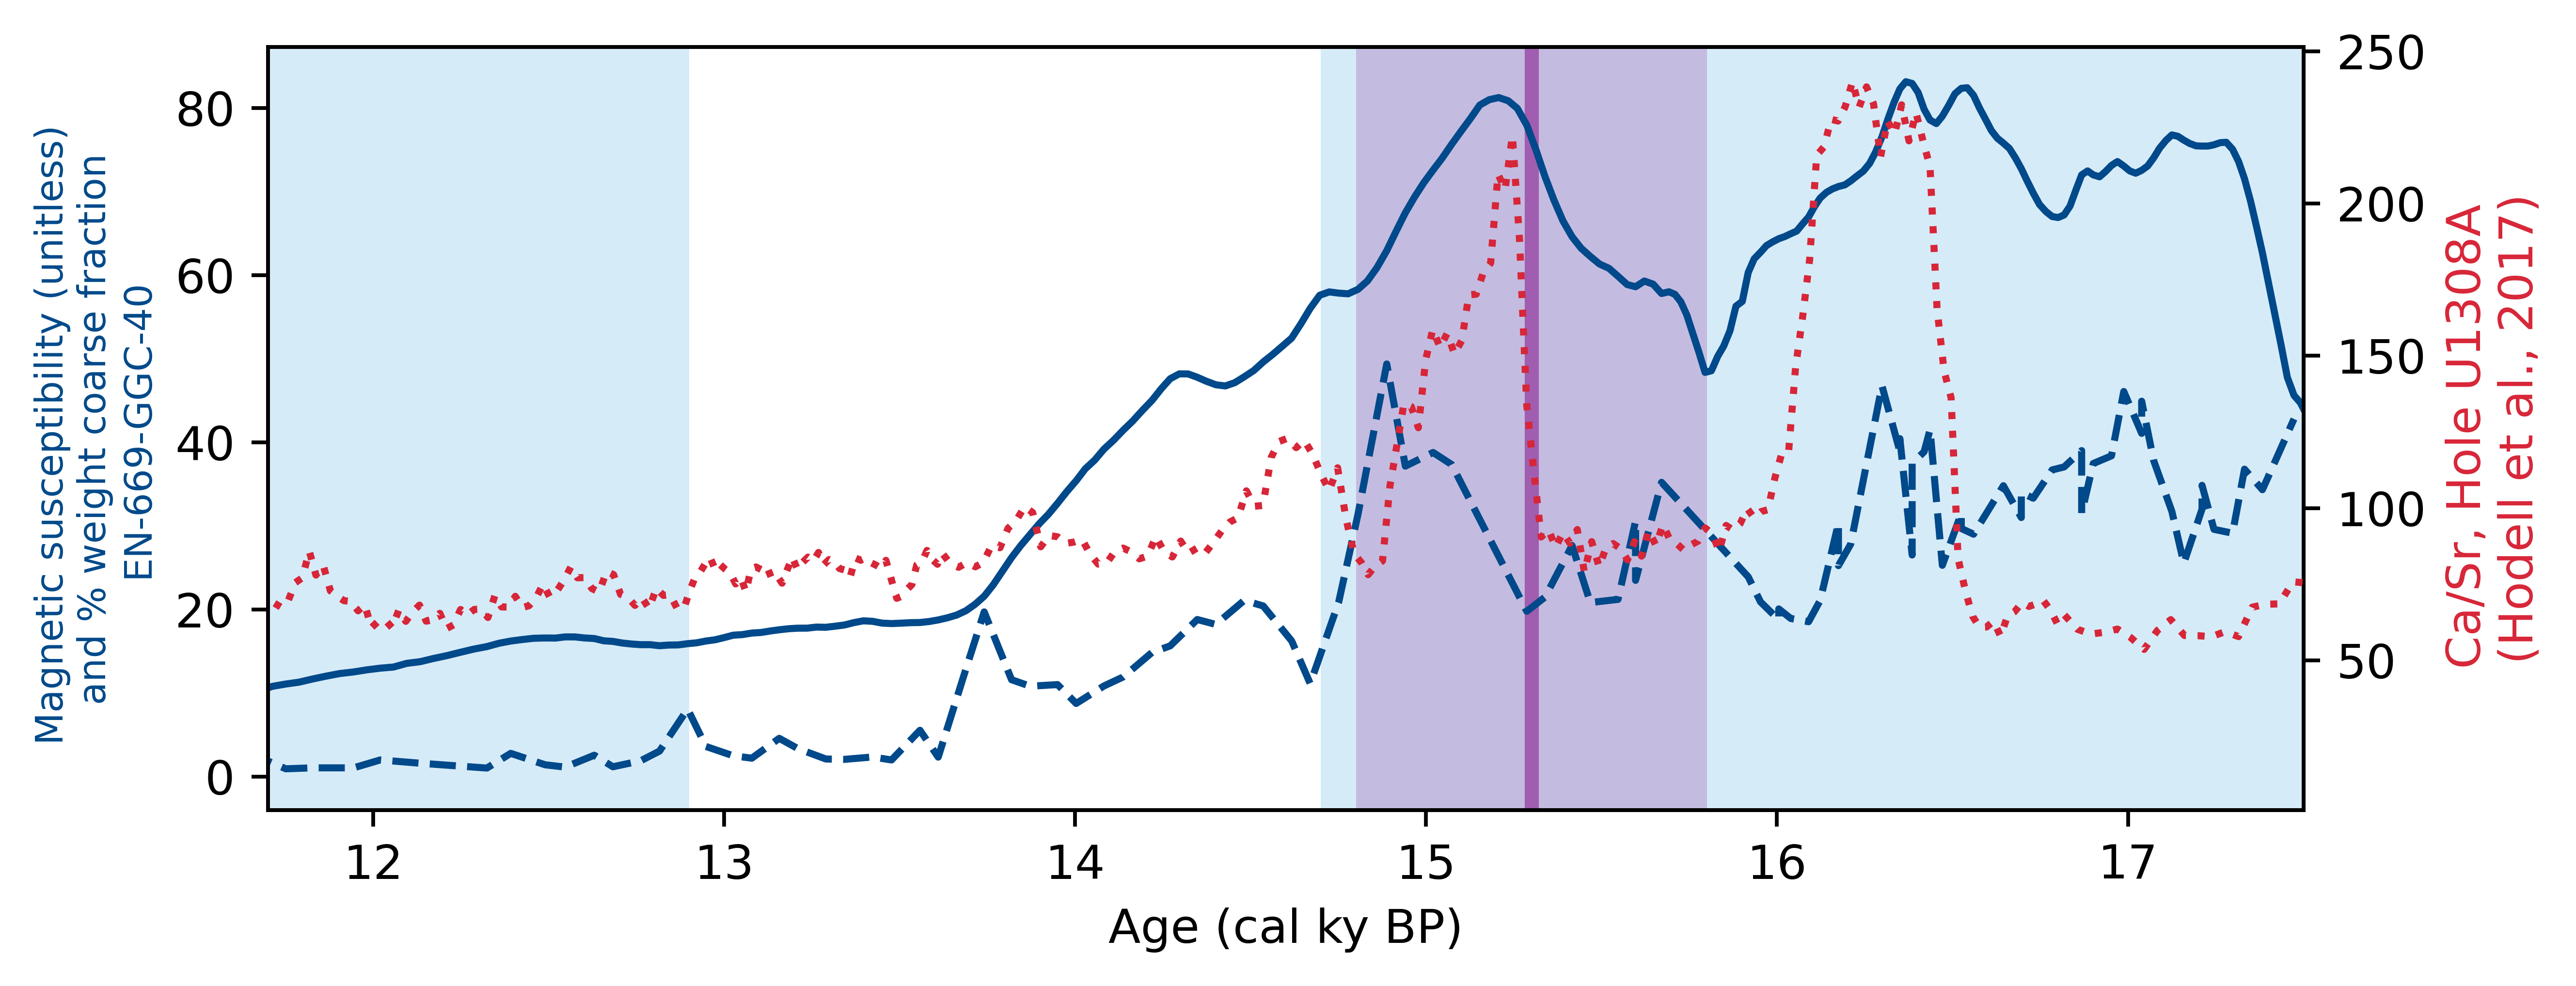

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

gold_c = '#ffb30f'
blue_c = "#00498a"
lblue_c = "#79bde9"
red= '#D72638'
Bar_color = lblue_c

df_data = pd.read_excel('/Users/jill.herlinger/Documents/Maine Research/data/Core sampling/EN-669 GGC-40 WASHING DATA.xlsx')
df_data = df_data[['Upper Depth', '% wgt Coarse Fraction']]
df_data['approx depth'] = df_data['Upper Depth'] + 0.5

df_age = pd.read_csv('/Users/jill.herlinger/Bacon_runs/EN-669-GGC-40/EN-669-GGC-40_119_ages.txt', sep='\t')
#df_age=df_age[['depth', 'mean']]

df_data = df_data.merge(df_age, left_on='approx depth', right_on='depth', how='left')
df_data = df_data[['approx depth', 'mean', '% wgt Coarse Fraction']]

df_mst = pd.read_excel('/Users/jill.herlinger/Documents/Maine Research/data/Core sampling/EN2108-S11-GC-E40_Graphs_agemodel.xlsx', header=14)
df_mst = df_mst[['SB DEPTH', 'MS1']]
df_mst['SB DEPTH'] = pd.to_numeric(df_mst['SB DEPTH'])

df_mst['age'] = df_age['mean']
df_mst['approx depth'] = df_mst['SB DEPTH'] +0.2

h=pd.read_csv('/Users/jill.herlinger/Documents/Maine Research/data/Not my data/Hodell 2017/data/pub/data/paleo/contributions_by_author/hodell2017/hodell2017u1308axrf.txt', comment='#', sep='\t', encoding='latin1')
xh=h['age_mean'].values
yh=h['Ca/Sr'].values

df_z=pd.read_excel('/Users/jill.herlinger/Documents/Maine Research/data/Not my data/knr198ggc35_ird.xlsx')

fig = plt.figure(figsize=(8, 3), dpi=700)

ax1 = fig.add_axes([0.15, 0.2, 0.75, 0.75])

x1 = (df_mst['age'].values / 1000)
y1 = (df_mst['MS1'].values)
x2 = (df_data['mean'].values / 1000)
y2 = (df_data['% wgt Coarse Fraction'].values)*100
x3 = df_z['Cal age (ka BP)']
y3 = df_z['IRD>250µm /g']

ax2 = ax1.twinx()

ax1.set_xlabel('Age (cal ky BP)')
ax1.set_ylabel(f'Magnetic susceptibility (unitless) \n and % weight coarse fraction \nEN-669-GGC-40', color="#00498a", fontsize=8)
ax2.set_ylabel(f'Ca/Sr, Hole U1308A \n(Hodell et al., 2017)', color=red)

plt.xlim(11.700, 17.500)

ax1.axvspan(12.900, 11.700, facecolor=Bar_color, alpha=0.3, edgecolor="none", label='Younger Dryas', zorder=1)
ax1.axvspan(18.000, 14.700, facecolor=Bar_color, alpha=0.3, edgecolor="none", label='Heinrich Stadial 1', zorder=1)

ax1.axvline(x=15.3, color='purple', linestyle='-', linewidth=3, zorder=2, alpha=0.5)
ax1.axvspan(14.8, 15.8, facecolor='purple', alpha=0.2, edgecolor="none", zorder=1)

ax1.plot(x1, y1, '#00498a', linestyle='-', zorder=3)
ax1.plot(x2,y2, '#00498a', linestyle='--', zorder=3)
#ax2.plot(x3,y3, red, linestyle='-.', zorder=3)

ax2.plot((xh/1000), yh, red, linestyle='dotted', zorder=3)

plt.show()

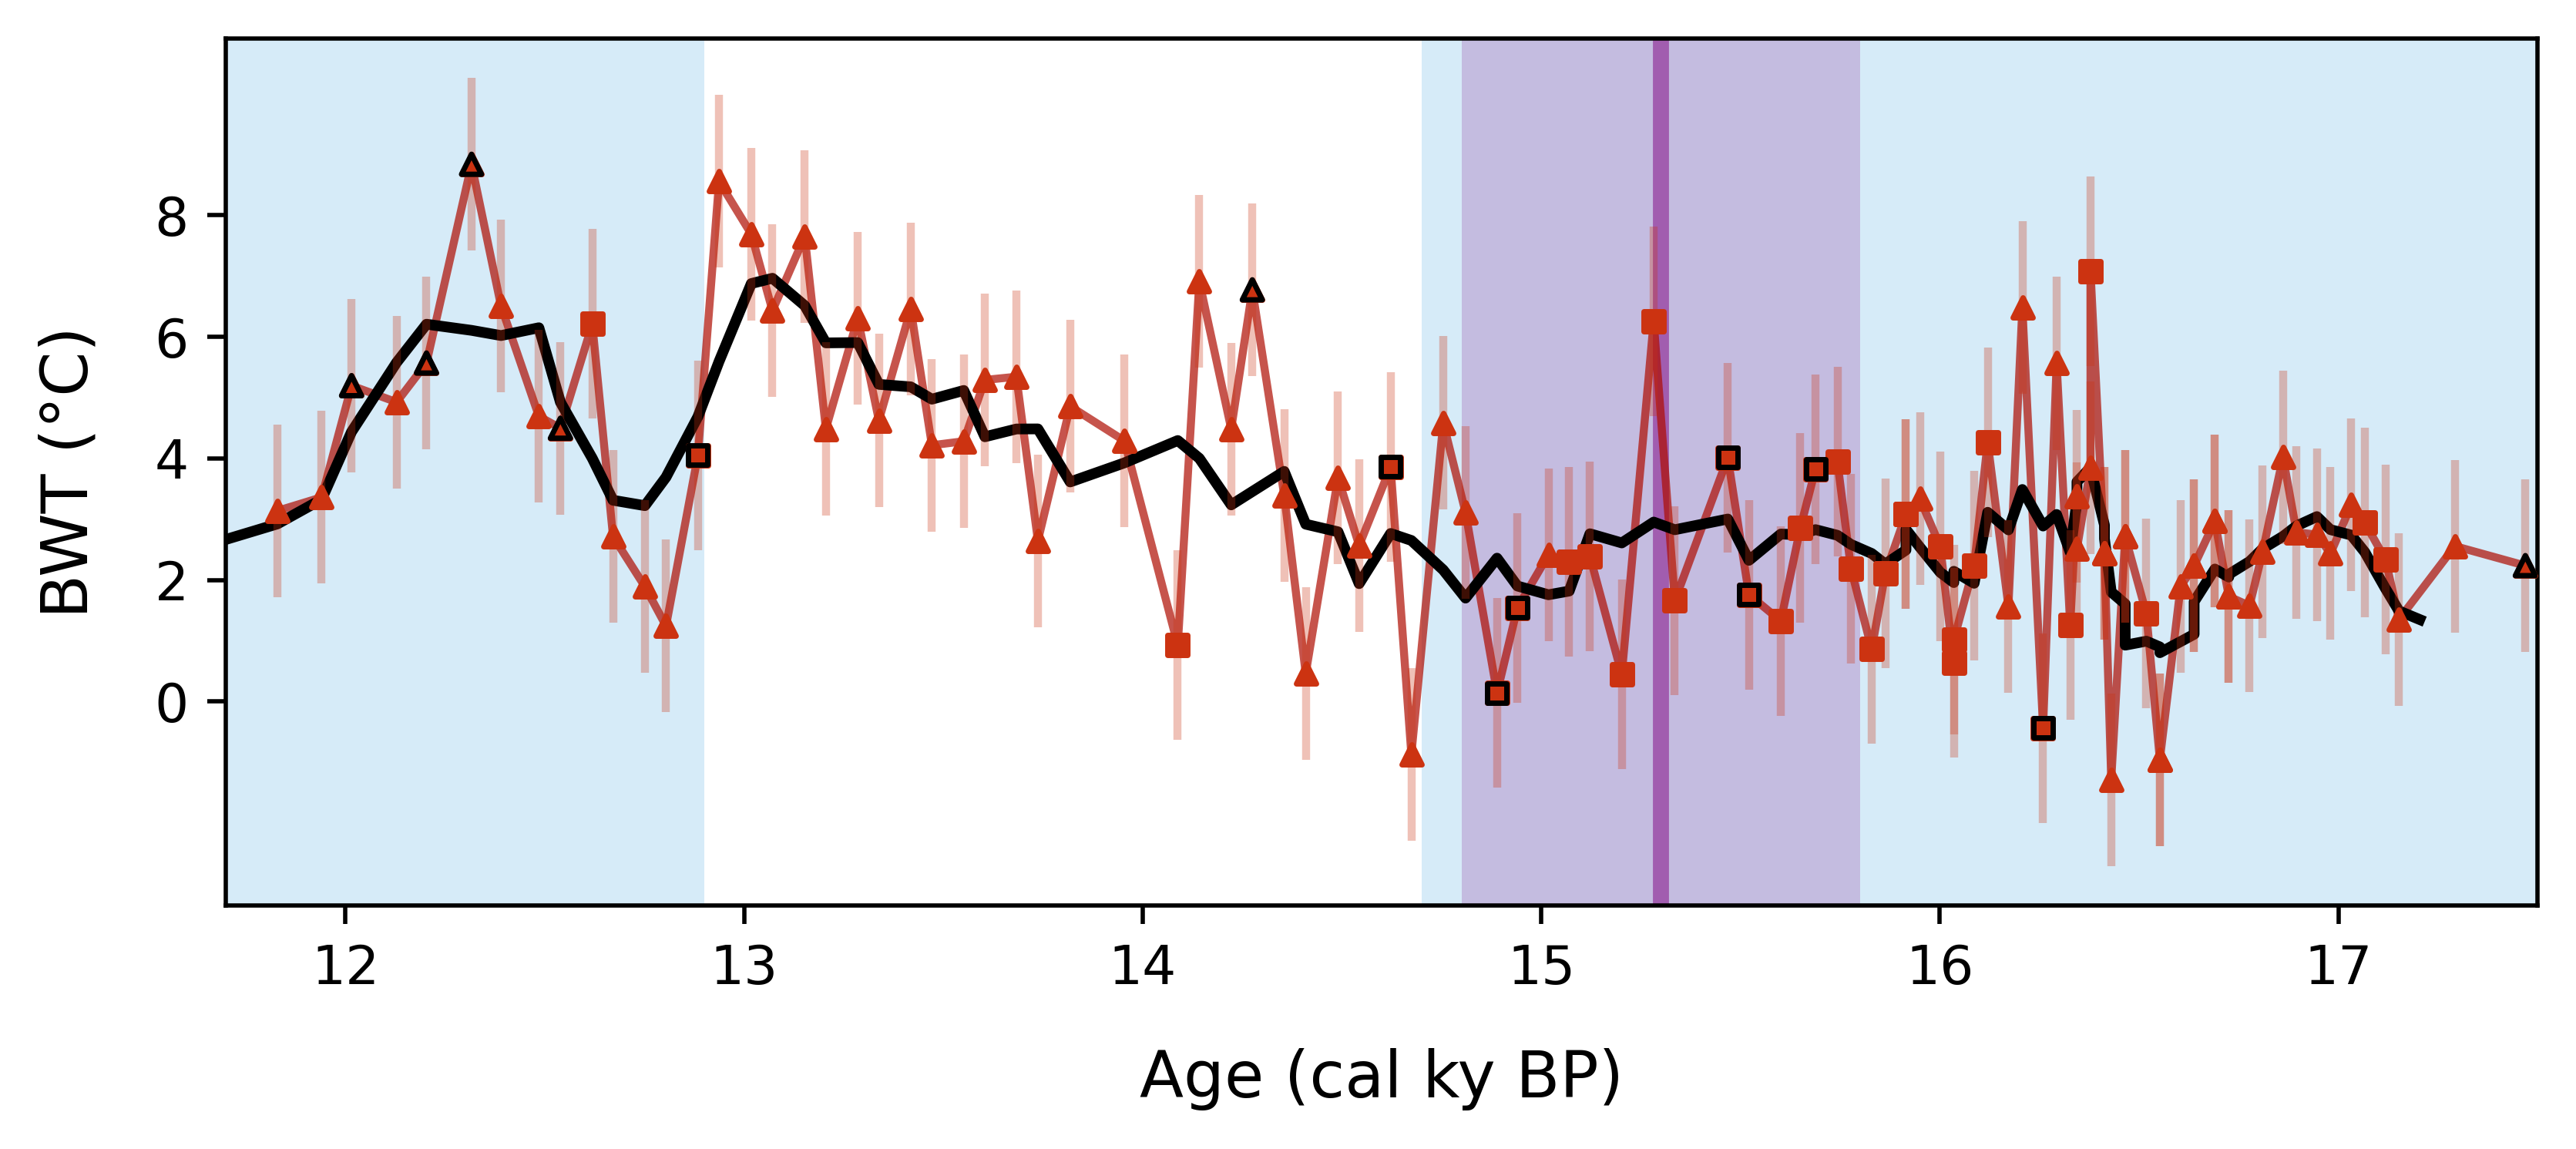

In [18]:
path='/Users/jill.herlinger/Documents/Maine Research/data/Paired d18O and Temp/EN669_GGC-40 Complete Dataset_July25.xlsx'

file = pd.read_excel(path, header=0)
file = file[file['mean'] > 11700]
file = file.dropna(subset=['BWT Temp'])
file = file.sort_values(by='mean')

i_flags=[348.5,
    353.5,
    356.5,
    363.5,
    428.5,
    585.5]

n_flags=[376.5,
    441.5,
    451.5,
    453.5,
    473.5,
    475.5,
    482.5,
    515.5]

file['flag'] = file['depth'].isin(i_flags + n_flags)
    
file_n=file[file['ICPMS species'] == "N. labradorica"]
file_i=file[file['ICPMS species'] == "I. helenae/norcrossi"]

file_nf=file_n[file_n['flag'] == True]
file_if=file_i[file_i['flag'] == True]

fig = plt.figure(figsize=(8, 3), dpi=500)
ax = fig.add_axes([0.15, 0.2, 0.75, 0.75])
plt.sca(ax)

plt.tick_params(axis='y', labelsize=10)
plt.tick_params(axis='x', labelsize=10)
plt.ylabel("Label", labelpad=10)
plt.xlabel("Label", labelpad=10)

plt.xlim(11.7, 17.5)
#plt.ylim(5, -1.5)
plt.sca(ax)

plt.axvspan(12.9, 11.7, facecolor=lblue_c, alpha=0.3, zorder=-5) 
plt.axvspan(18.0, 14.7, facecolor=lblue_c, alpha=0.3, zorder=-5) 
plt.axvline(x=15.3, color='purple', linestyle='-', linewidth=3, zorder=-4, alpha=0.5)        
plt.axvspan(14.8, 15.8, facecolor='purple', alpha=0.2, edgecolor="none", zorder=-5)

plt.xlabel('Age (cal ky BP)', fontsize=12)
plt.ylabel("BWT (°C)", fontsize=12)

X = file['mean'] / 1000
Y = file['BWT Temp']
Y_err = file['BWT Error']

mask = X.notna() & Y.notna() & Y_err.notna()

X = X[mask]
Y = Y[mask]
Y_err = Y_err[mask]

plt.plot(X, Y, c='#ae0c00', alpha=0.7)

Xn = file_n['mean'] / 1000
Yn = file_n['BWT Temp']

Xnf = file_nf['mean'] / 1000
Ynf = file_nf['BWT Temp']

# mask = Xn.notna() & Yn.notna()
# Xn = Xn[mask]
# Yn = Yn[mask]

Xi = file_i['mean'] / 1000
Yi = file_i['BWT Temp']

Xif = file_if['mean'] / 1000
Yif = file_if['BWT Temp']

# mask = Xi.notna() & Yi.notna()
# Xi = Xi[mask]
# Yi = Yi[mask]

color='#CC3311'

df['rolling avg t'] = df['BWT Temp'].rolling(window=5, center=True).mean()
plot_df = df[['mean','BWT Temp', 'rolling avg t']].dropna()

plt.plot(plot_df['mean']/1000, plot_df['rolling avg t'], color='black', linewidth=2)

plt.errorbar(X, Y, yerr=Y_err, color=color, alpha=0.3, linestyle='none')

plt.scatter(Xn,Yn, s=13, marker='s', c=color, zorder=10)
plt.scatter(Xi, Yi, s=14, marker='^', c=color, zorder=10)

plt.scatter(Xnf,Ynf, s=13, marker='s', facecolor='none', edgecolor='black', zorder=10)
plt.scatter(Xif, Yif, s=14, marker='^', facecolor='none', edgecolor='black', zorder=10)


plt.yticks([0, 2, 4, 6, 8])


plt.show()